# End of Snowball Earth: Climate model with a bifurcation

This notebook introduces a **simple climate model** to explore the rapid warming at the end of a hypothesized Snowball Earth period. In our model of the Earth's climate, we conceive of the Earth surface and atmosphere as a single reservoir. The surface temperature is determined by the balance of incoming and outgoing radiation. The model accounts for i) the greenhouse effect and ii) the temperature-dependent snow and ice cover, which in turn controls how much sunlight is reflected and is thus not available to warm the surface. It is a simplified version of the classic models by Sellers and Budyko. A gentle introduction to one-reservoir energy balance models can be found [here](https://doi.org/10.48550/arXiv.1907.11067).

We will investigate the **Snowball Earth hypothesis** using this model. We will describe how the gradual emission of greenhouse gases by volcanoes can induce a catastrophic transition from a Snowball Earth mode to a largely ice-free state.

The predicted sudden shift is due to a **bifurcation**, also referred to as a tipping point. At the bifurcation, a small change in a parameter value, in our case the magnitude of the greenhouse effect, completely changes the dynamics of the system. The sudden change is enabled by a strong positive feedback: as temperature increases, ice melts, causing the Earth's surface to absorb more sunlight, thus increasing temperatures further.

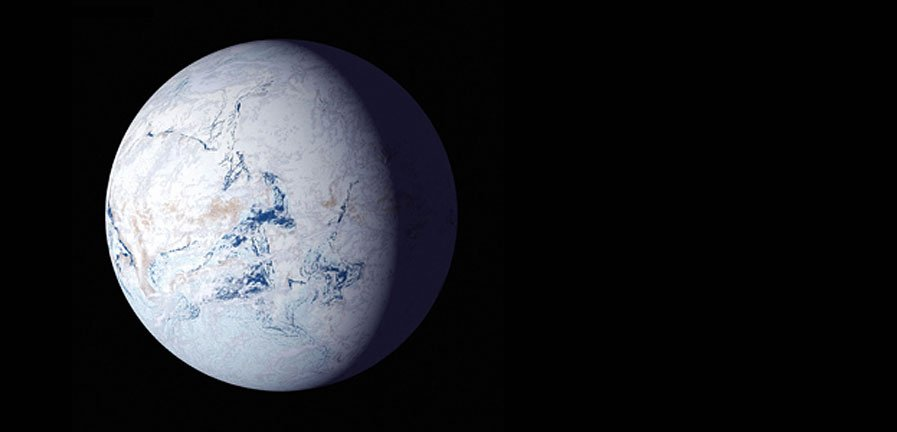

*Artist's depiction of Snowball Earth, from* [NASA Astrobiology](https://astrobiology.nasa.gov/news/fossils-explain-how-life-coped-during-snowball-earth/)

## Climate model

Our model is implemented in Python. We first need to load various packages and set parameters.

In [73]:
import numpy as np
from scipy.constants import Stefan_Boltzmann as sigma
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from collections.abc import Iterable
year = (60 * 60 * 24 * 365.25) # seconds in a year
T0 = 273.15 # 0 Celsius in K

C = 4e8  # [J m-2 K-1] effective heat capacity per unit area
albedo_snow = 0.75 # [-]
albedo_nosnow = 0.25 # [-]
T_half = 255 # half the earth is snow/ice covered at this temperature
T_range = 15 # temperature range over which ice cover transitions from 0 to 1
emiss = 0.67 # [-]; emissivity
S0 = 342 # [W m-2]; spatially and temporally averaged incoming radiation flux [per unit area], accounting for night

### Energy balance of the Earth's surface

The **control volume** of our reservoir encompasses the atmosphere and the Earth's surface. We would like its average temperature to be representative of the average temperature at the surface, while bearing in mind there are [substantial limitations](https://doi.org/10.5194/esd-11-1195-2020) to describing the Earth's climate using a single reservoir.

**Conservation of energy** underpins our climate model. We will track the reservoir's internal energy $U$ through the energy balance
$$\frac{\mathrm{d}U}{\mathrm{d}t} = S_{\mathrm{abs}} - S_{\mathrm{em}}.$$
Here, $S_{\mathrm{abs}}$ is the inflow of energy through the absorbtion of solar radiation (mainly in the visible and near-infrared part of the spectrum). The outflow is given by the $S_{\mathrm{em}}$, the emitted radiation (in the longwave infrared). These quantities refer to the entire surface of the Earth. To facilitate interpretation, we will normalize them by the total surface area, so that, say, $S_{\mathrm{abs}}$ is the average incoming radiative flux in W m$^{-2}$.

The **change in surface temperature** can be inferred by assuming that a change in temperature $\mathrm{d}T$ corresponds to a change in internal energy $\mathrm{d}U = C\,\mathrm{d}T$, where the proportionality constant $C$ is an effective heat capacity. Thus,
$$C\,\frac{\mathrm{d}T}{\mathrm{d}t} = S_{\mathrm{abs}} - S_{\mathrm{em}}.$$


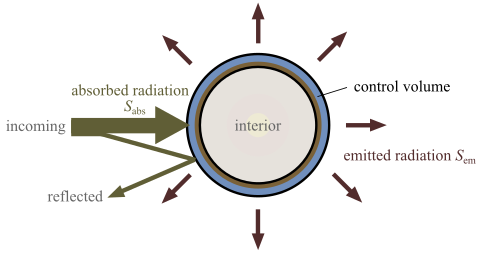

*To model the energy balance of the Earth's atmosphere and surface (control volume), we consider the absorption of incoming solar radiation and the emission of thermal radiation. Exchanges with the Earth's interior are neglected.*

### Absorbed radiation and Earth's albedo

We model the absorbed radiation $S_{\mathrm{abs}}$ as a fraction of the incoming solar radiation at the top of the atmosphere $S_0 = 342\,\mathrm{W}$ when averaged over the entire year and the Earth's surface.

The brightness of the surface governs the fraction of $S_0$ that is absorbed. We refer to the brightness as albedo $a \in [0, 1]$ (literally, whiteness). A surface with albedo $a$ receiving incoming radiation $S_0$ reflects $a\,S_0$, while the remainder is absorbed:
$$S_{\mathrm{abs}} = (1 - a)\,S_0.$$
The brighter the surface, the more radiation is reflected rather than absorbed.


In [74]:
def S_abs(T):
    return (1 - albedo(T)) * S0

The **albedo depends on temperature** because colder temperatures induce greater snow and ice cover. For simplicity, we assume that for very cold (warm) temperatures essentially the entire Earth is ice-covered (ice-free), with a gradual transition in between. This dependence captures the ice–temperature feedback, as an increase in temperature will lower the albedo, increasing $S_{\mathrm{abs}}$.

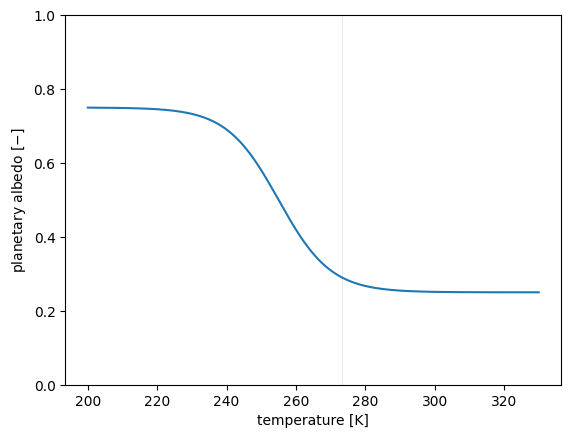

In [75]:
def albedo(T):
    frac = 0.5 * (1 + np.tanh((T - T_half) / (T_range)))
    return albedo_nosnow * frac + albedo_snow * (1 - frac)

# plot the dependence
T_grid = np.linspace(200, 330, num=261)
fig, ax = plt.subplots()
ax.axvline(T0, lw=0.5, c='#dddddd')
ax.plot(T_grid, albedo(T_grid))
ax.set_xlabel('temperature [K]')
ax.set_ylim((0, 1))
_ = ax.set_ylabel('planetary albedo [$-$]')

Snow and ice have a large albedo (they are bright and absorb little radiation). You can change the corresponding parameter ```albedo_snow``` in the first code cell. You can also play with the snow-free albedo ```albedo_nosnow```, the temperature at which half the Earth is ice-covered ```T_half```, and the width of the transition ```T_range```. The default parameter values are of the right order of magnitude, but it is difficult to constrain the values tightly because this relationship is such an oversimplification.

### Emitted radiation and greenhouse effect

The emitted radiation also increases with temperature according to the Stefan-Boltzmann law
$$S_{\mathrm{em}} = \varepsilon \, \sigma \, T^4.$$
The emitted radiation increases with $T^4$: Doubling the (absolute) temperature corresponds to an increase in emission by a factor of 16. The parameter $\sigma$ is the Stefan-Boltzmann constant. The emissivity $\varepsilon \in [0, 1]$ is a measure of how effective the surface is at emitting thermal radiation.

The **greenhouse effect can be captured through the emissivity** when $\varepsilon < 1$. Very roughly speaking, greenhouse gases such as carbon dioxide "trap" the radiation emitted by the ocean or land surface, reducing the radiation that escapes from the Earth. An increase in greenhouse gases from volcanoes or anthropogenic emissions will reduce $\varepsilon$, causing the Earth to heat up. This is because in steady state, the net radiation $$S_{\mathrm{net}} \equiv S_{\mathrm{em}} - S_{\mathrm{abs}} = 0$$
vanishes (in words, absorbed and emitted radiation are in balance). In the simplest case, $S_{\mathrm{abs}}$ will remain constant, so that a decrease in $\varepsilon$ needs to be compensated by an increase in $T$.

In our model, we consider $\varepsilon$ to be a parameter. For modeling the end of Snowball Earth, we will slowly decrease $\varepsilon$ in response to an accumulation of greenhouse gases in the atmosphere.


In [76]:
def S_em(T, emiss=emiss):
    return emiss * sigma * T ** 4

def net_radiation(T, emiss=emiss):
    return S_abs(T) - S_em(T, emiss=emiss)

### Simulations

To get a sense of the model predictions, we will simulate the temperature over half a century. Your divine intervention will determine the initial temperature $T_0$, but then the Earth system will evolve according to our model. We will keep the greenhouse effect ($\varepsilon$) fixed at, roughly, contemporary values.

For relatively warm initial temperatures of $T \approx 270\,\mathrm{K}$, the modeled temperature approaches a steady state of $T \approx 285\,\mathrm{K}$, representative of today's Earth. The adjustment time scale is on the order of a decade.



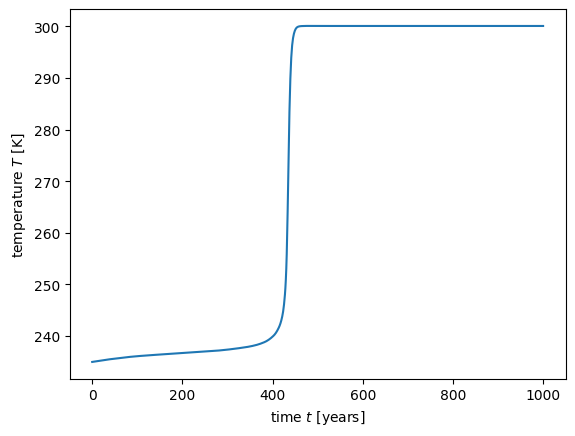

In [88]:
T0 = 235 # initial temperature, in K; default: 270

# emissivity for simulation
emiss_sim = 0.557 # 0.67 default; do not change for now

# numerical solution; do not worry about the details
t_eval = np.linspace(0, 1000 * year, num=1000)
def _dTdt(t, T):
    return net_radiation(T, emiss=emiss_sim) / C
sol = solve_ivp(
    _dTdt, [t_eval[0], t_eval[-1]], [T0], t_eval=t_eval, method='LSODA')
T = sol.y[0,:]

# plotting
fig, ax = plt.subplots()
ax.plot(t_eval, T)
ax.set_ylabel('temperature $T$ [K]')
ax.set_xlabel('time $t$ [years]')
ticks = np.linspace(t_eval[0], t_eval[-1], num=6)
ax.set_xticks(ticks)
_ = ax.set_xticklabels((ticks/year).astype(int))


### Think-pair-share

Change the value of the initial temperature $T_0$ in the first line. What happens for very warm initial temperatures? What happens for very cold initial temperatures? How could the behavior be explained?

## Steady state solutions

Our model permits multiple steady states for the chosen emissivity, as revealed by your previous experiments. These include a warm world with little ice cover and a cold snowball world, with high and low albedo, respectively. But are these all possible steady states?

In **steady state**, the inflow of energy $S_\mathrm{abs}$ equals the outflow $S_\mathrm{em}$. In our model, inflow and outflow depend on temperature $T$. We can see see for which temperatures $S_\mathrm{abs} = S_\mathrm{em}$ by plotting them against $T$.

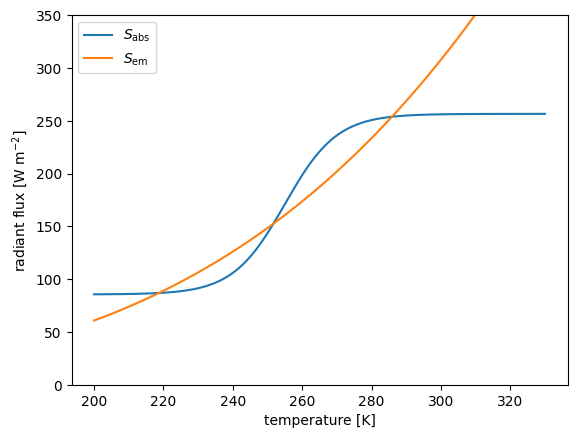

In [78]:
S_abs_grid = S_abs(T_grid)
S_em_grid = S_em(T_grid, emiss=emiss)
fig, ax = plt.subplots()
ax.plot(T_grid, S_abs_grid, label='$S_{\mathrm{abs}}$')
ax.plot(T_grid, S_em_grid, label='$S_{\mathrm{em}}$')
ax.set_ylim((0, 350))
ax.set_ylabel('radiant flux [W m$^{-2}$]')
ax.set_xlabel('temperature [K]')
_ = ax.legend(loc='upper left')

**The curves intersect at three points, each corresponding to a steady-state solution.** If the temperature starts out at one of these points, it will remain unchanged indefinitely. In other words, there exists a steady state. To see this, note that $S_\mathrm{abs} = S_\mathrm{em}$ implies that vanishing net radiation $S_{\mathrm{net}} \equiv S_\mathrm{abs} - S_\mathrm{em} = 0$, so that
$$C\,\frac{\mathrm{d}T}{\mathrm{d}t} =S_{\mathrm{net}} = 0.$$
The temperature $T$ does not change.

In dynamical system theory, we also call these points at which the time derivative vanishes fixed points.

### Stability

These three fixed points are qualitatively different. You will notice that your earlier simulations converged to the one near 220 K and the one near 280 K but not to the one in the middle near 260 K. This is because the first two are stable points but the one in the middle is an unstable point.

Whether a fixed point is stable or not depends on whether the net radiation is positive or negative if the temperature is just above that of the fixed point.

**Stable fixed points** are stable because positive net radiation at warmer temperatures will pull the temperatures back down.
Imagine the temperature were 300 K, higher than that of the rightmost fixed point. We see that the emitted radiation (orange) is larger than the absorbed radiation (blue): The net radiation $S_{\mathrm{net}} < 0$, causing the temperature to decrease ($\mathrm{d}T/\mathrm{d}t < 0$). We indicate this at the bottom of the plot with an arrow pointing to the left, i.e., toward lower temperatures. The temperature will continue to decrease until it reaches the fixed point. Similarly, for $T = 280\,K$ just below the fixed point, the net radiation is positive and the temperature will increase until it reaches the fixed point. The same reasoning applies to the leftmost fixed point.


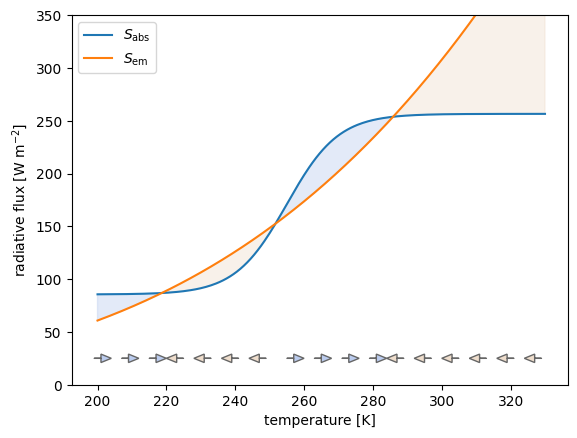

In [79]:
fig, ax = plt.subplots()
ac = {1: '#bbccee', -1: '#eeddcc'}
ax.plot(T_grid, S_abs_grid, label='$S_{\mathrm{abs}}$')
ax.plot(T_grid, S_em_grid, label='$S_{\mathrm{em}}$')
ax.fill_between(
    T_grid, S_em_grid, S_abs_grid, where=(S_em_grid > S_abs_grid),
    color=ac[-1], alpha=0.4)
ax.fill_between(
    T_grid, S_abs_grid, S_em_grid, where=(S_abs_grid > S_em_grid),
    color=ac[1], alpha=0.4)
S_mid_grid = 0.5 * (S_abs_grid + S_em_grid)
direction_grid = np.sign(S_abs_grid - S_em_grid)
for _T, _direction in list(zip(T_grid, direction_grid))[::16]:
  ax.arrow(
      _T - _direction, 25, 2 * _direction, 0, head_width=8, head_length=3,
      fc=ac[int(_direction)], ec='#666666')
ax.set_ylim((0, 350))
ax.set_ylabel('radiative flux [W m$^{-2}$]')
ax.set_xlabel('temperature [K]')
_ = ax.legend(loc='upper left')

The **unstable fixed point** behaves in a different way. Apply analogous reasoning to understand what happens when the temperature is slightly above that of the central fixed point: what is the net radiation and in which direction is the temperature "pulled"?

# Volcanic emissions and bifurcations

Bifurcations occur when fixed points emerge or disappear as an external parameter changes. In our case, the external parameter is the emissivity $\varepsilon$, which slowly decreases due to volcanic activity. A summary of the key ideas can be found [in these lecture notes](https://courses.seas.harvard.edu/climate/eli/Courses/EPS281r/Sources/Snowball/more/notes-energy_balance_0d.pdf).

Let's plot the fixed points and their stability as a function of the emissivity.


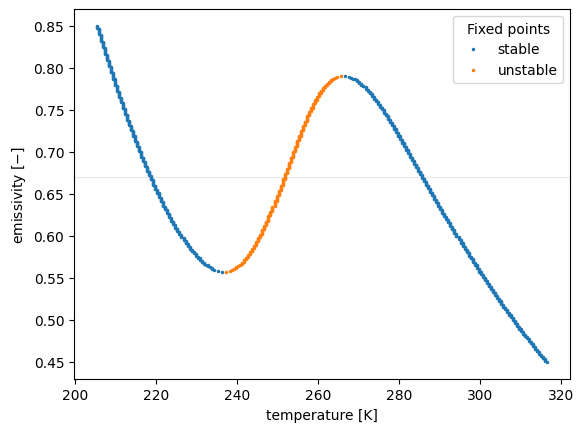

In [80]:
emiss_grid = np.linspace(0.45, 0.85, num=384)

# evaluate fixed points on a temperature grid T_grid
# fast but minor discretization issues
def fixed_points(T_grid, emiss=emiss):
    def _fixed_points_single(_emiss):
        net_grid = net_radiation(T_grid, emiss=_emiss)
        # compare the signs of adjacent T_grid points
        sign_changes = np.signbit(net_grid[1:] * net_grid[:-1])
        s_f = (np.signbit(net_grid)[1:][sign_changes]) #stable: True
        # look for where net radiation changes sign
        T_f = 0.5 * (T_grid[1:][sign_changes] + T_grid[:-1][sign_changes])
        return T_f, s_f
    return [_fixed_points_single(em) for em in np.atleast_1d(emiss)]
fp = fixed_points(T_grid, emiss=emiss_grid)

# plot it
cols= {True: '#1f77b4', False: '#ff7f0e'}
fig, ax = plt.subplots()
handles = {}
labels = {True: 'stable', False: 'unstable'}
ax.axhline(emiss, c='#dddddd', lw=0.5)
for _emiss, _fp in zip(emiss_grid, fp):
    for _T, _s in zip(*_fp):
        handles[_s] = ax.plot(
            _T, _emiss, linestyle='none', marker='o', ms=1.5, c=cols[_s],
            label=labels[_s])[0]
ax.legend(handles=handles.values(), title='Fixed points')
ax.set_ylabel('emissivity [$-$]')
_ = ax.set_xlabel('temperature [K]')

We have created a **bifurcation diagram**. To make it easier compare with the previous plots, we're showing the parameter on the vertical axis and the state on the horizontal axis, in a deviation from the bifurcation diagrams we looked at earlier.

Let's start with the baselineline emissivity we looked at just before, shown by a horizontal line. We see that it intersects the curve three times, each intersection corresponding to a fixed point. The left- and right-most are stable, the one in the middle is unstable.

**Bifurcations** arise as we change the emissivity. Assume the emissivity increases gradually (moving upward on the plot). The unstable point and the rightmost stable point approach each other. At some point, these two fixed points will coincide and disappear: a bifurcation.

😱 Mathematicians distinguish different types of bifurcations. The one we just discovered is called a fold bifurcation or, equivalently, saddle-node bifurcation. Jeffrey Chasnov's online textbook contains a concise mathematical [introduction to one-dimensional bifurcations](https://math.libretexts.org/Bookshelves/Differential_Equations/Differential_Equations_(Chasnov)/08%3A_Nonlinear_Differential_Equations/8.02%3A_One-Dimensional_Bifurcations).


### Sudden changes

A fold bifurcation predisposes a modeled system to sudden changes, also called catastrophes. Imagine a hothouse world with a mean (steady-state) temperature of 280 K and an emissivity of around 0.7. As the emissivity gradually increases (weaker greenhouse effect), the steady-state temperature (corresponding to the stable fixed point) will gradually decrease. Until the bifurcation is reached. At this point, the stable equilbrium disappears, and our system will be drawn to the left, i.e. to lower temperatures. According to our model, we expect a Snowball Earth to form.

## The end of Snowball Earth

According to the Snowball Earth hypothesis, average temperatures on the order of 220 K once prevailed, and large parts of the Earth were frozen. This stable steady state was enabled by the high albedo of snow and ice. Such cold temperatures are not amenable to the efficient uptake of carbon dioxide through weathering or photosynthesis. A gradual increase in greenhouse gas concentrations from volcanic emissions strengthened the greenhouse effect. Temperatures increased gradually up to a point, at which a rapid transition to high temperatures $\gtrsim$270 K occurred.

### In pairs
Use the model to explain how volcanic activity pushed our planet out of the surmised Snowball state.
1.   Assume a temperature of 220 K at peak "Snowball Earth" and that it corresponded to a stable steady state. What emissivity does it correspond to? Does that emissivity also permit a snow-free stable state?
2.   Imagine greenhouse gas concentrations increased gradually, on time scales much longer than the response time of our model. This means that, to a very good approximation, the temperature at a given emissivity will be equal to the steady-state temperature of a stable fixed point corresponding to the emissivity. Create a sketch of the system's trajectory on top of the bifurcation diagram.
3.   Extend your sketch to show what happens as a bifurcation is approached and crossed. You are encouraged to return to the simulations at the beginning of the notebook: Adjust the initial temperature and emissivity according to your needs. Explain in simple terms what Earth system processes captured by our model promoted the system's behavior.
4.   Imagine that after the system has crossed the bifurcation, the emissivity were to increase again. Sketch the trajectory in a different color. Characterize the behavior of the system.


## In-class experiment: Buckling
Buckling provides another example of a bifurcation in Earth System Science, as it is implicated in volcanic and tectonic deformation, or the deformation of sea ice.

In everyday life, you can see it when you press down on a business card, a flyer or an acrylic ruler. If you only press down a little, the object will remain straight and vertical. As you increase the pressure, at some point the object will deflect to one side.

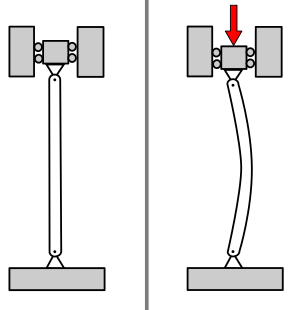

[*Buckling of a beam*](https://commons.wikimedia.org/wiki/File:Buckled_column.svg). *Initially, the beam is vertical, even under application of an axial load at the top. As the load is increased, the beam will eventually buckle to the side, a bifurcation. The horizontal position of either end does not change in this experiment, but there will be a non-zero average deflection when the beam has buckled.*


### Group exercise
You are given a business card, and your task is to explore its buckling behavior. Based on your observations of how the card behaves as you slowly change the force with which you push on it, create a diagram of fixed points of the objects mean deflection from the vertical (say, positive to the right) as a function of the applied load. Identify the bifurcations that arise. Can you induce hysteretic behavior similar to the end of the snowball earth where a return to the pre-bifurcation parameter value (in this case, the applied force) does not permit a return to the pre-bifurcation state (in this case, the deflection)?